## LSTM and ConvNet Based Architecture for $P(C_t)$ as a Probability Map


### Performance Comparison on the Training and Test Set

Five time steps, 15 minutes up to $t_0$

## Imports

In [2]:
from tensorflow.keras import layers, models                                             # type: ignore
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout                                # type: ignore

### Choose lead time here

In [150]:
lead_time = 1

### This depends on the grid spacing

In [151]:
resolution = 11

### Read data

These are the appropriate data for the map, corrected from outliers 

In [152]:
test_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/test-Dakar-map-features-many-timesteps-lt{lead_time}.csv", index_col=False)
test_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/test-Dakar-map-target-many-timesteps-lt{lead_time}.csv", index_col=False)

train_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/train-Dakar-map-features-many-timesteps-lt{lead_time}.csv", index_col=False)
train_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/train-Dakar-map-target-many-timesteps-lt{lead_time}.csv", index_col=False)

In [153]:
raw_test_X = test_data_X
raw_train_X, raw_validation_X, train_y, validation_y = train_test_split(train_data_X, train_data_y, test_size=0.3, random_state=12)

### Defining and choosing headers for each timesteps

In [154]:
# Initial headers for time periods
t0 = "year,month,day,hour,minute,"
t15 = "year_15,month_15,day_15,hour_15,minute_15,"
t30 = "year_30,month_30,day_30,hour_30,minute_30,"
t45 = "year_45,month_45,day_45,hour_45,minute_45,"
t60 = "year_60,month_60,day_60,hour_60,minute_60,"

# Initialize empty strings for loc, wp, ds, sz for t0 (current), t15, t30, t45, and t60
loc = wp = ds = sz = "" 
loc_15 = wp_15 = ds_15 = sz_15 = "" 
loc_30 = wp_30 = ds_30 = sz_30 = "" 
loc_45 = wp_45 = ds_45 = sz_45 = "" 
loc_60 = wp_60 = ds_60 = sz_60 = "" 

# Loop to generate the string for each time period (current, +15, +30, +45, +60 minutes)
for i in range(1, 6):
    # For the current time (t0)
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    
    # For t15 (15 minutes later)
    loc_15 += f"lat{i}_15,lon{i}_15,"
    wp_15 += f"wp{i}_15,"
    ds_15 += f"ds{i}_15,"
    sz_15 += f"size{i}_15,"
    
    # For t30 (30 minutes later)
    loc_30 += f"lat{i}_30,lon{i}_30,"
    wp_30 += f"wp{i}_30,"
    ds_30 += f"ds{i}_30,"
    sz_30 += f"size{i}_30,"
    
    # For t45 (45 minutes later)
    loc_45 += f"lat{i}_45,lon{i}_45,"
    wp_45 += f"wp{i}_45,"
    ds_45 += f"ds{i}_45,"
    sz_45 += f"size{i}_45,"
    
    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    ds_60 += f"ds{i}_60,"
    sz_60 += f"size{i}_60,"

# Concatenate all headers for t0, t15, t30, t45, t60
headers = (t0 + loc + wp + ds + sz + 
           t15 + loc_15 + wp_15 + ds_15 + sz_15 + 
           t30 + loc_30 + wp_30 + ds_30 + sz_30 + 
           t45 + loc_45 + wp_45 + ds_45 + sz_45 + 
           t60 + loc_60 + wp_60 + ds_60 + sz_60)

print(headers)


year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,lon3,lat4,lon4,lat5,lon5,wp1,wp2,wp3,wp4,wp5,ds1,ds2,ds3,ds4,ds5,size1,size2,size3,size4,size5,year_15,month_15,day_15,hour_15,minute_15,lat1_15,lon1_15,lat2_15,lon2_15,lat3_15,lon3_15,lat4_15,lon4_15,lat5_15,lon5_15,wp1_15,wp2_15,wp3_15,wp4_15,wp5_15,ds1_15,ds2_15,ds3_15,ds4_15,ds5_15,size1_15,size2_15,size3_15,size4_15,size5_15,year_30,month_30,day_30,hour_30,minute_30,lat1_30,lon1_30,lat2_30,lon2_30,lat3_30,lon3_30,lat4_30,lon4_30,lat5_30,lon5_30,wp1_30,wp2_30,wp3_30,wp4_30,wp5_30,ds1_30,ds2_30,ds3_30,ds4_30,ds5_30,size1_30,size2_30,size3_30,size4_30,size5_30,year_45,month_45,day_45,hour_45,minute_45,lat1_45,lon1_45,lat2_45,lon2_45,lat3_45,lon3_45,lat4_45,lon4_45,lat5_45,lon5_45,wp1_45,wp2_45,wp3_45,wp4_45,wp5_45,ds1_45,ds2_45,ds3_45,ds4_45,ds5_45,size1_45,size2_45,size3_45,size4_45,size5_45,year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60

## Preprocessing

In [155]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [156]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [157]:
to_scale = f"{wp}{wp_15}{wp_30}{wp_45}{wp_60}{sz}{sz_15}{sz_30}{sz_45}{sz_60}{ds}{ds_15}{ds_30}{ds_45}{ds_60}".rstrip(',')

In [158]:
t = f"{t0}{t15}{t30}{t45}{t60}".rstrip(',')

In [159]:
def prepare(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t.split(',')[:-1])
    return df

### Transforming

In [160]:
transform = True
if transform:
    train_X = prepare(raw_train_X)
    validation_X = prepare(raw_validation_X)
    test_X = prepare(raw_test_X)

### Scaling

In [161]:
scaler = load(f'Dakar-map-lt{lead_time}-lstm.bin')
model = tf.keras.models.load_model(f'Dakar-map-lt{lead_time}-lstm.keras')

std_X_train = scaler.transform(train_X)
std_X_val = scaler.transform(validation_X)
std_X_test = scaler.transform(test_X)

In [162]:
x_train = std_X_train.reshape(len(train_X), 5, 30)
y_train = tf.reshape(train_y, (len(train_y), resolution, resolution))

x_val = std_X_val.reshape(len(validation_X), 5, 30)
y_val = tf.reshape(validation_y, (len(validation_y), resolution, resolution))

x_test = std_X_test.reshape(len(test_X), 5, 30)
y_test = tf.reshape(test_data_y, (len(test_data_y), resolution, resolution))

### Save model

In [163]:
n_test = test_data_y.shape[0]

In [164]:
pred_y_train = model.predict(x_train).flatten()
pred_y_test = model.predict(x_test).flatten()

1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [165]:
idx = []

for i in range(y_test.shape[0]):
    idx.append(np.mean(y_test[i]))

In [166]:
idx_max = np.argmax(idx)

In [167]:
y_test[idx_max]

<tf.Tensor: shape=(11, 11), dtype=float64, numpy=
array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])>

In [168]:
raw_test_X.iloc[idx_max, :]

year      2020.00
month        9.00
day          5.00
hour        23.00
minute      15.00
           ...   
ds1_60      17.03
ds2_60      43.60
ds3_60      52.00
ds4_60      64.35
ds5_60      64.50
Name: 3555, Length: 150, dtype: float64

In [169]:
pred_y_test.reshape(n_test, resolution, resolution)[idx_max]

array([[0.49706635, 0.34964976, 0.45602053, 0.5911939 , 0.48737332,
        0.5045025 , 0.489222  , 0.36340255, 0.35839987, 0.302473  ,
        0.24392168],
       [0.42167696, 0.37852597, 0.44264936, 0.52063197, 0.59858793,
        0.54879564, 0.49497658, 0.32431325, 0.364778  , 0.33251974,
        0.31127104],
       [0.40929398, 0.47727686, 0.5751511 , 0.5349386 , 0.6148773 ,
        0.6116826 , 0.45469835, 0.45992398, 0.4781026 , 0.36788604,
        0.3751557 ],
       [0.4413703 , 0.4902768 , 0.599828  , 0.6008183 , 0.58278257,
        0.57268375, 0.592436  , 0.52057695, 0.48396483, 0.32478637,
        0.27549878],
       [0.40879765, 0.43128842, 0.57811266, 0.6549558 , 0.62693965,
        0.6321707 , 0.72774607, 0.62806803, 0.56339943, 0.3933634 ,
        0.42182553],
       [0.3750321 , 0.49620473, 0.6320541 , 0.67234766, 0.65129566,
        0.69156075, 0.67235553, 0.6893804 , 0.66620237, 0.53642553,
        0.56955296],
       [0.4469414 , 0.54258823, 0.65334564, 0.6101434 , 0.

## ROC

Maybe I should also plot the Precision-Recall ROC curve

In [170]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [171]:
auc_train = roc_auc_score(y_train.numpy().flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.numpy().flatten(), pred_y_test)

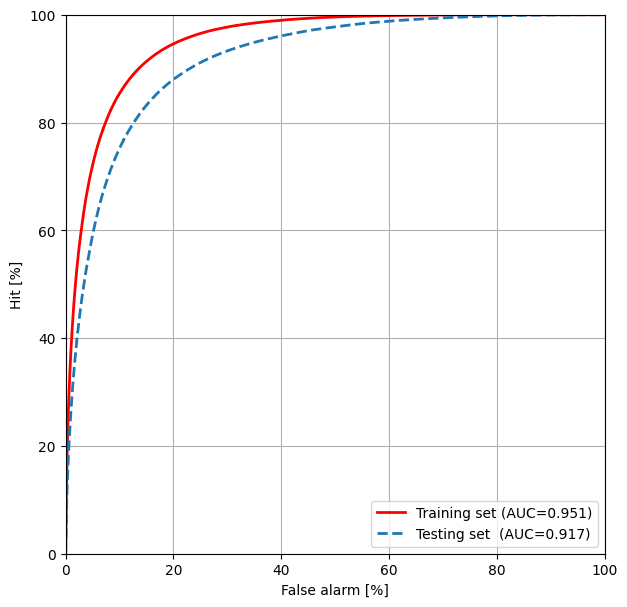

In [172]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.numpy().flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.numpy().flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Reliability diagram

In [173]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

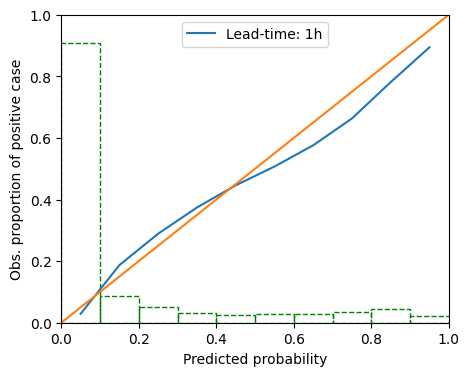

In [174]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.numpy().flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: {lead_time}h")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [175]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [176]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [177]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [178]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [179]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [180]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

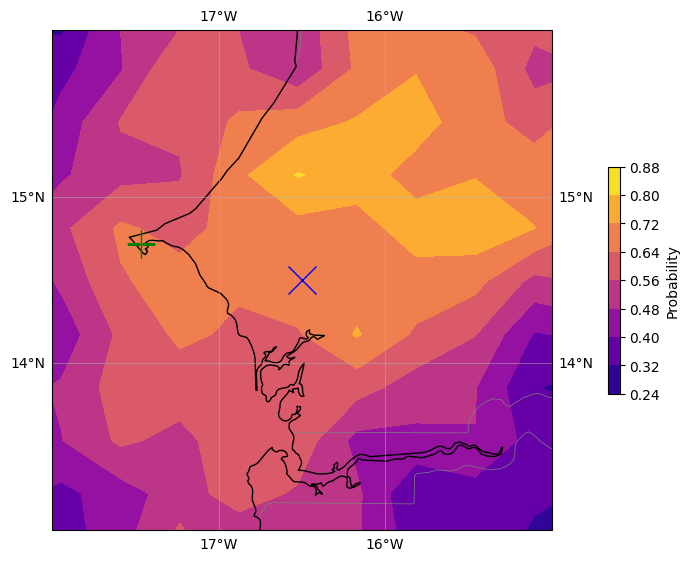

In [181]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[idx_max], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

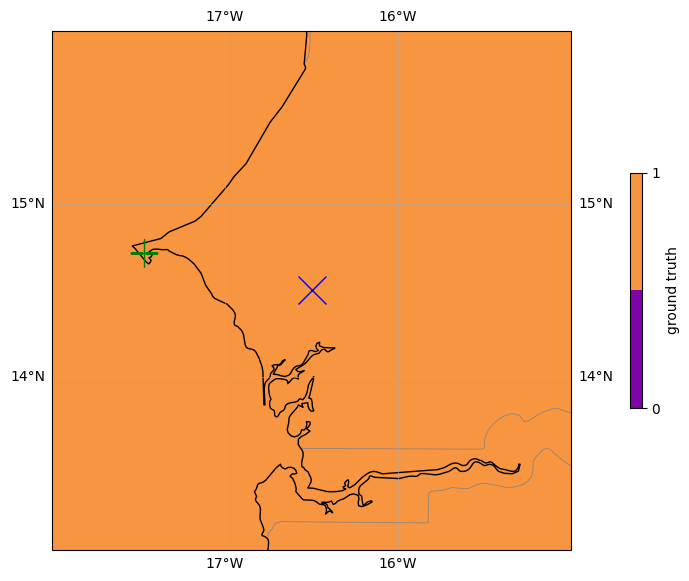

In [182]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, y_test[2024], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

In [183]:
#model.save(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/Dakar-map-t{lead_time}.keras')

In [184]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [185]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [186]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [187]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [188]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [189]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

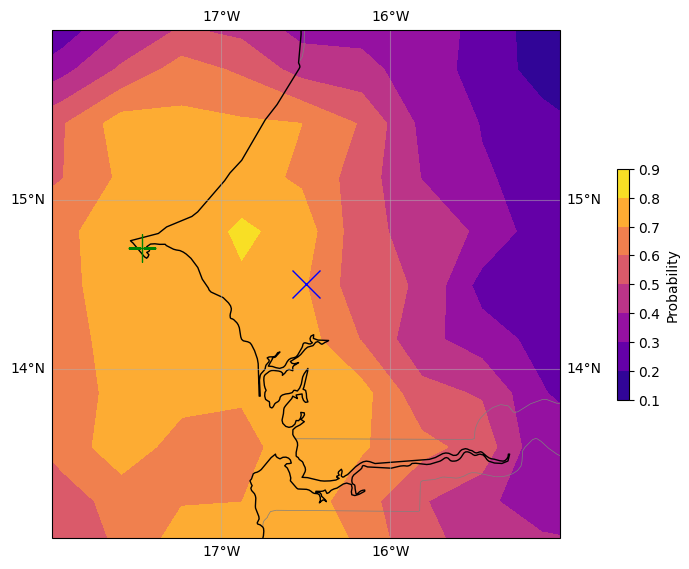

In [195]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[2024], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

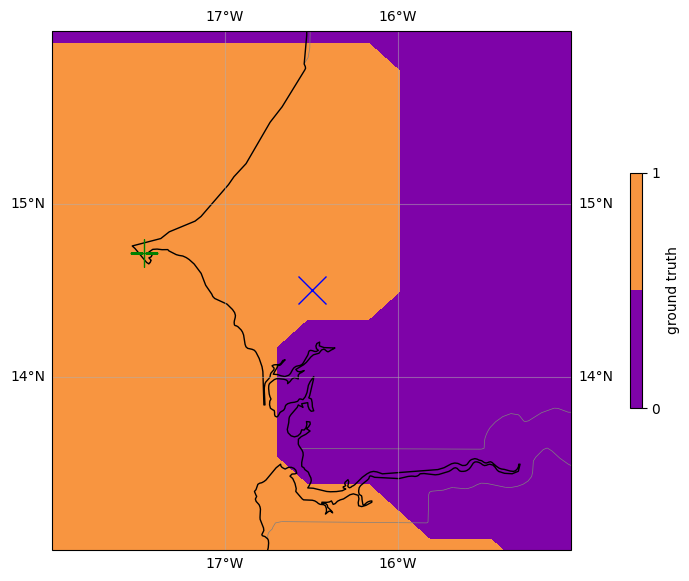

In [191]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, y_test[2024], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

### Verification using Fraction Skill Score

Some other forms of verification may be needed

### FSS

In [192]:
def calculate_fss(forecast, observation, neighborhood_size=1):
    """
    Calculate the Fraction Skill Score (FSS) for a binary forecast and observation over a grid.
    Handles the case where both forecast and observation are all zeros.
    
    Args:
    - forecast (2D numpy array): Binary forecast data (1 for event, 0 for no event).
    - observation (2D numpy array): Binary observation data (1 for event, 0 for no event).
    - neighborhood_size (int): Size of the neighborhood window for fraction calculation.
    
    Returns:
    - FSS (float): The fraction skill score between forecast and observation.
    """
    forecast = np.array(forecast)
    observation = np.array(observation)
    
    if forecast.shape != observation.shape:
        raise ValueError("Forecast and observation must have the same shape.")
    
    # If both forecast and observation are all zeros, return perfect FSS (1)
    if np.all(forecast == 0) and np.all(observation == 0):
        return 1.0
    
    def compute_fraction(data, neighborhood_size):
        rows, cols = data.shape
        fraction = np.zeros_like(data, dtype=float)
        for i in range(rows):
            for j in range(cols):
                r_min = max(0, i - neighborhood_size)
                r_max = min(rows, i + neighborhood_size + 1)
                c_min = max(0, j - neighborhood_size)
                c_max = min(cols, j + neighborhood_size + 1)
                neighborhood = data[r_min:r_max, c_min:c_max]
                fraction[i, j] = np.mean(neighborhood)
        return fraction
    
    forecast_fraction = compute_fraction(forecast, neighborhood_size)
    observation_fraction = compute_fraction(observation, neighborhood_size)
    
    numerator = np.sum((forecast_fraction - observation_fraction) ** 2)
    denominator = np.sum(forecast_fraction ** 2 + observation_fraction ** 2)
    
    # To avoid division by zero, check if denominator is zero
    if denominator == 0:
        return 0.0  # If there's no signal at all, set FSS to 0
    
    fss = 1 - (numerator / denominator)
    return fss


In [193]:
def calculate_fss_for_all_instances(forecasts, observations, neighborhood_size=1):
    """
    Calculate the FSS for each forecast-observation pair in the dataset and return the average FSS.
    
    Args:
    - forecasts (list of 2D numpy arrays): List of forecast grids for all instances.
    - observations (list of 2D numpy arrays): List of observation grids for all instances.
    - neighborhood_size (int): Size of the neighborhood window for fraction calculation.
    
    Returns:
    - average_fss (float): The average FSS over all instances.
    - fss_scores (list of floats): The FSS score for each instance.
    """
    fss_scores = []
    
    # Loop over each forecast-observation pair
    for forecast, observation in zip(forecasts, observations):
        fss = calculate_fss(forecast, observation, neighborhood_size)
        fss_scores.append(fss)
    
    # Compute the average FSS
    average_fss = np.mean(fss_scores)
    
    return average_fss, fss_scores

#### Computing the FSS for different combinations of threshold and spatial scale

In [ ]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
number_of_neighbours = [1, 2, 3]

fss = []

for t in thresholds:
    for scale in number_of_neighbours:
        fss.append(calculate_fss_for_all_instances(pred_y_test.reshape(n_test, resolution, resolution)>=t, y_test, neighborhood_size=scale)[0])

In [125]:
fss_lt = np.array(fss).reshape(len(thresholds), len(number_of_neighbours)).T

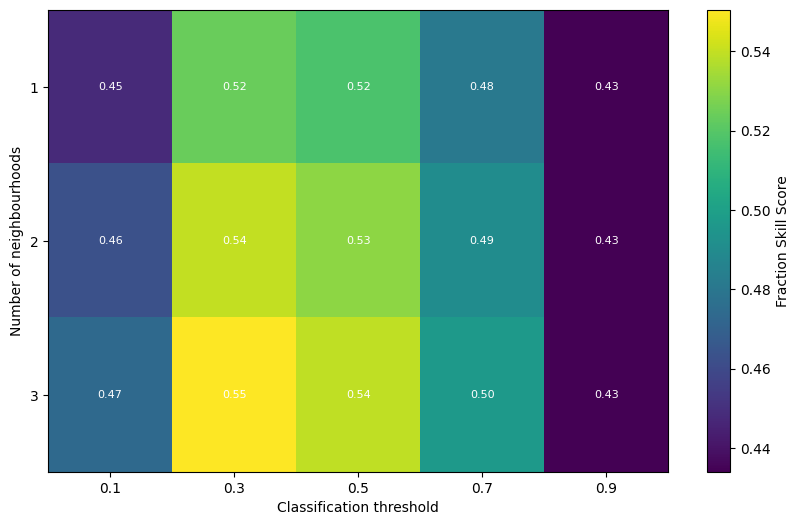

In [127]:
fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(fss_lt, cmap='viridis', aspect='auto')

# Add a colorbar
cbar = plt.colorbar(cax)
cbar.set_label('Fraction Skill Score')

# Annotate each cell with its value, no need for positional adjustment in imshow
for i in range(fss_lt.shape[0]):
    for j in range(fss_lt.shape[1]):
        value = fss_lt[i, j]
        ax.text(j, i, f'{value:.2f}', 
                ha='center', va='center', 
                color='white', fontsize=8)

ytick_labels = [str(tick) for tick in number_of_neighbours] 
ax.set_yticks(np.array(number_of_neighbours)-1)
ax.set_yticklabels(ytick_labels)


xtick_labels = [str(tick) for tick in thresholds] 
ax.set_xticks(range(5))
ax.set_xticklabels(xtick_labels)


# Set labels and title
plt.xlabel('Classification threshold')
plt.ylabel('Number of neighbourhoods')
plt.show()

In [132]:
raw_test_X.iloc[idx_max,:][t60.split(",")[:-1]]

year_60      2020.0
month_60        9.0
day_60          5.0
hour_60        22.0
minute_60      15.0
Name: 2997, dtype: float64

array([1.4715435e-03, 5.2316219e-04, 7.5010001e-05, ..., 3.3941776e-03,
       5.1755472e-03, 1.7992565e-02], dtype=float32)

In [135]:
pred_y_test.reshape(n_test, resolution, resolution)[1998]

array([[0.66310924, 0.6595447 , 0.7154065 , 0.8322181 , 0.8322181 ,
        0.8322181 , 0.8322181 , 0.8322181 , 0.8322181 , 0.7570198 ,
        0.73450524],
       [0.6537399 , 0.6681572 , 0.7481438 , 0.8322181 , 0.8322181 ,
        0.8322181 , 0.8322181 , 0.8322181 , 0.8322181 , 0.778155  ,
        0.7567032 ],
       [0.6397999 , 0.6525912 , 0.72910094, 0.8322181 , 0.8322181 ,
        0.81763864, 0.81079155, 0.81869924, 0.7864056 , 0.77623624,
        0.7932851 ],
       [0.393231  , 0.493267  , 0.6951413 , 0.8322181 , 0.8322181 ,
        0.81044734, 0.80250853, 0.8139107 , 0.7714191 , 0.60010403,
        0.5649545 ],
       [0.29314002, 0.3626265 , 0.5547388 , 0.6649369 , 0.811972  ,
        0.8164784 , 0.69241095, 0.6806213 , 0.6958692 , 0.55058503,
        0.4715581 ],
       [0.11426967, 0.22778042, 0.44897303, 0.54482836, 0.63917786,
        0.63530475, 0.55553675, 0.5642918 , 0.5534901 , 0.40939397,
        0.31851977],
       [0.08349635, 0.09851962, 0.15419538, 0.23155141, 0.

### Finding $t_0$ based on a chosen index

In [145]:
raw_test_X.iloc[2024,:][t60.split(",")[:-1]]

year_60      2020.0
month_60        8.0
day_60          9.0
hour_60        17.0
minute_60      15.0
Name: 2024, dtype: float64